<a href="https://colab.research.google.com/github/pmudproject/analysis-equity-volatility/blob/main/analysisvollie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install yfinance pandas matplotlib statsmodels

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [5]:
aapl = yf.download("AAPL", start="2020-01-01")
sp500 = yf.download("^GSPC", start="2020-01-01")

/tmp/ipykernel_671/2880306320.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download("AAPL", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_671/2880306320.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


In [6]:
aapl.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [7]:
data = pd.DataFrame()

aapl_returns = aapl["Close"].pct_change()
sp500_returns = sp500["Close"].pct_change()

data["aapl"] = aapl_returns
data["sp500"] = sp500_returns

data = data.dropna()

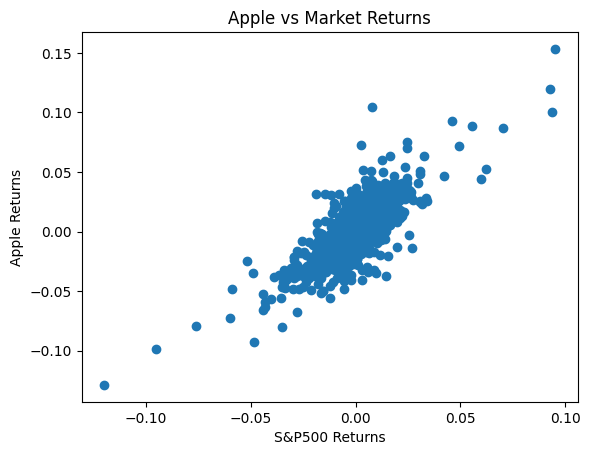

In [8]:
plt.scatter(data["sp500"], data["aapl"])
plt.xlabel("S&P500 Returns")
plt.ylabel("Apple Returns")
plt.title("Apple vs Market Returns")
plt.show()

In [9]:
X = data["sp500"]
X = sm.add_constant(X)

y = data["aapl"]

model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   aapl   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     2382.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          6.66e-316
Time:                        03:21:55   Log-Likelihood:                 4607.8
No. Observations:                1556   AIC:                            -9212.
Df Residuals:                    1554   BIC:                            -9201.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.102      0.2

In [10]:
window = 60

In [11]:
window = 60
betas = []

for i in range(window, len(data)):

    y_window = data["aapl"].iloc[i-window:i]
    X_window = data["sp500"].iloc[i-window:i]

    X_window = sm.add_constant(X_window)

    model = sm.OLS(y_window, X_window).fit()

    betas.append(model.params["sp500"])

In [12]:
beta_series = pd.Series(betas, index=data.index[window:])

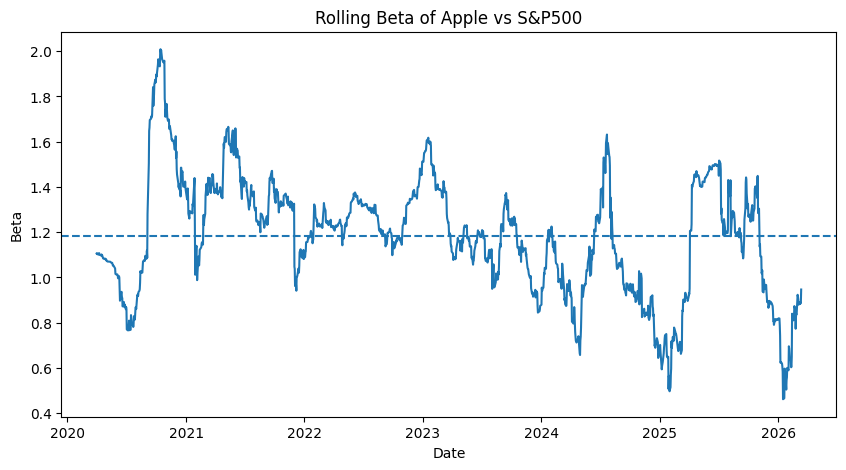

In [13]:
plt.figure(figsize=(10,5))

plt.plot(beta_series)

plt.axhline(beta_series.mean(), linestyle="--")

plt.title("Rolling Beta of Apple vs S&P500")
plt.ylabel("Beta")
plt.xlabel("Date")

plt.show()

In [14]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 27.9 MB/s eta 0:00:00


In [15]:
from pmdarima import auto_arima

In [17]:
auto_model = auto_arima(
    data["aapl"],
    seasonal=False,
    trace=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-7767.615, Time=1.61 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-7763.737, Time=0.22 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-7771.421, Time=0.45 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-7770.829, Time=0.38 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-7770.979, Time=0.92 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-7770.250, Time=0.60 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-7771.992, Time=1.19 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-7768.080, Time=0.29 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-7769.248, Time=0.40 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-7769.979, Time=0.40 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-7766.183, Time=0.50 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-7774.652, Time=1.32 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-7772.779, Time=0.40 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-7773.268, Time=0.74 sec
 ARIMA(3,0,1)(0,0,0

In [18]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 36.2 MB/s eta 0:00:00


In [19]:
from arch import arch_model

In [21]:
returns_scaled = data["aapl"] * 100

In [22]:
garch_model = arch_model(
    returns_scaled,
    vol='Garch',
    p=1,
    q=1
)

results = garch_model.fit()

print(results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 9292.178607945152
Iteration:      2,   Func. Count:     16,   Neg. LLF: 207864.56324876138
Iteration:      3,   Func. Count:     24,   Neg. LLF: 3805.648125218695
Iteration:      4,   Func. Count:     31,   Neg. LLF: 3502.018947106957
Iteration:      5,   Func. Count:     39,   Neg. LLF: 3102.9497848449764
Iteration:      6,   Func. Count:     44,   Neg. LLF: 3102.9093694512903
Iteration:      7,   Func. Count:     49,   Neg. LLF: 3102.9082999278867
Iteration:      8,   Func. Count:     54,   Neg. LLF: 3102.9082649591564
Iteration:      9,   Func. Count:     59,   Neg. LLF: 3102.9082637130878
Iteration:     10,   Func. Count:     63,   Neg. LLF: 3102.9082637133342
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3102.9082637130878
            Iterations: 10
            Function evaluations: 63
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results       

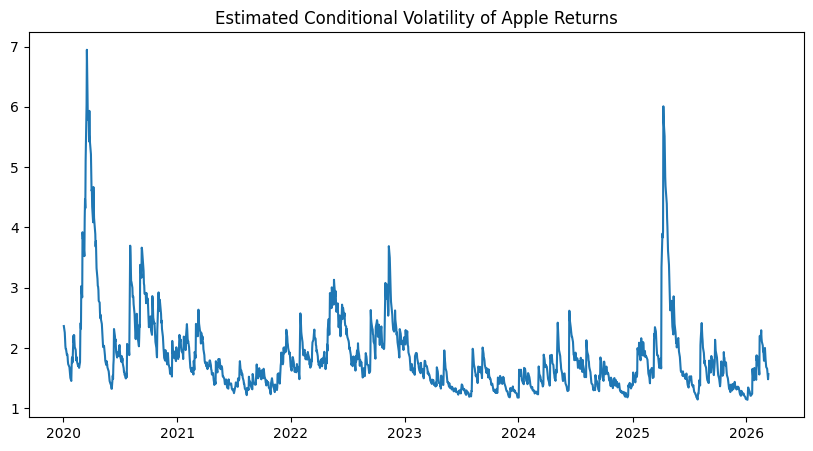

In [23]:
volatility = results.conditional_volatility

plt.figure(figsize=(10,5))

plt.plot(volatility)
plt.title("Estimated Conditional Volatility of Apple Returns")

plt.show()

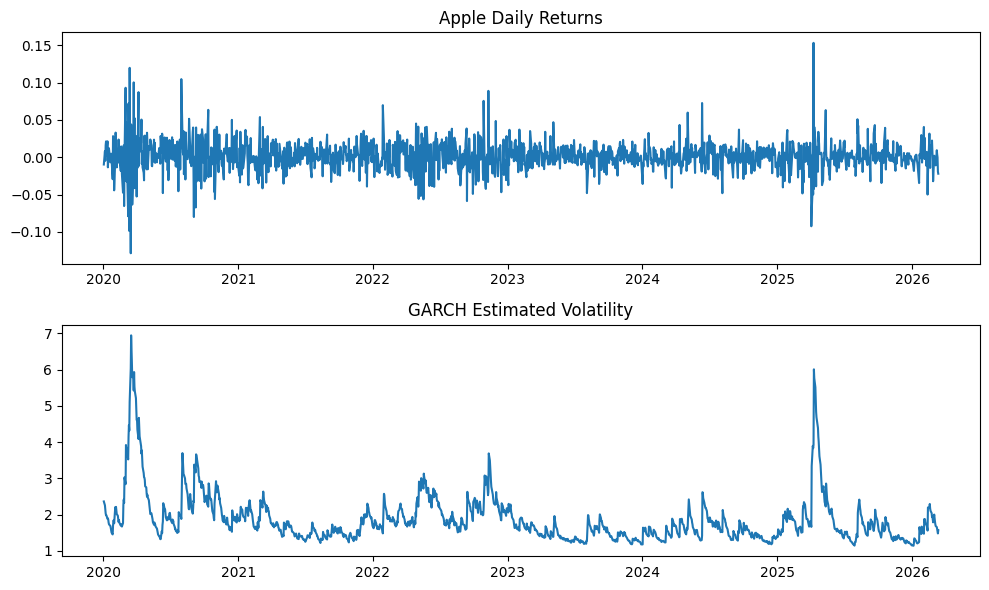

In [26]:
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(data["aapl"])
plt.title("Apple Daily Returns")

plt.subplot(2,1,2)
plt.plot(volatility)
plt.title("GARCH Estimated Volatility")

plt.tight_layout()
plt.show()

In [27]:
tickers = ["AAPL","MSFT","NVDA","AMZN"]

data = yf.download(tickers, start="2020-01-01")["Close"]
returns = data.pct_change().dropna()

/tmp/ipykernel_671/1237174759.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01")["Close"]
[*********************100%***********************]  4 of 4 completed


In [28]:
from arch import arch_model

results = {}

for stock in tickers:

    r = returns[stock]*100

    model = arch_model(r, vol='Garch', p=1, q=1)
    res = model.fit(disp="off")

    alpha = res.params["alpha[1]"]
    beta = res.params["beta[1]"]

    persistence = alpha + beta

    results[stock] = persistence

In [29]:
for stock,value in results.items():
    print(stock, "volatility persistence:", round(value,3))

AAPL volatility persistence: 0.963
MSFT volatility persistence: 0.955
NVDA volatility persistence: 0.94
AMZN volatility persistence: 0.881


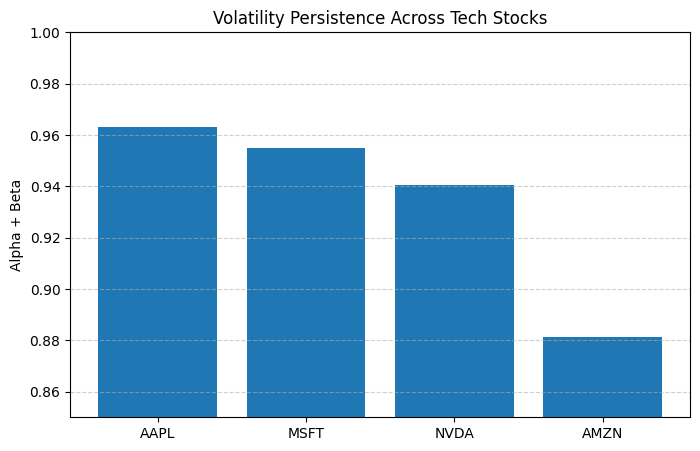

In [31]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.title("Volatility Persistence Across Tech Stocks")
plt.ylabel("Alpha + Beta")

plt.ylim(0.85,1.0)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()